# 🌍 CO₂ Emissions & Economic Growth — EDA & Hypothesis Testing

**Author:** `Diana`  
**Date:** `27.05.2026`  
**Branch:** `Diana`

---
## Business Case

A coalition of environmental researchers is tracking whether the Paris Agreement has delivered measurable results. Using country-level data from 2014 to 2020, they investigate whether economic growth and carbon emissions are genuinely decoupling  or, whether wealthy nations are simply exporting their footprint. The findings aim to hold regional climate commitments accountable with data.

### Hypothesis 1

> **Has the CO₂ intensity of GDP (co2 / GDP) declined across regions from 2014 to 2020 — and does the answer change depending on how we measure emissions?**

This is tested in two scenarios: Scenario A uses fossil and industrial emissions only (co2 / GDP, the optimistic view); Scenario B adds land-use change (co2_luc / GDP, the honest view). If decoupling holds in Scenario A but weakens in Scenario B, it suggests wealthier regions have shifted emissions rather than eliminated them.

### Hypothesis 2

> **Where renewable energy adoption has grown, has CO₂ intensity actually fallen — and where is the gap largest?**

Following Hypothesis 1, we ask why intensity declined (or didn't). Then compare annual changes in CO₂ intensity (d_co2_int) against annual changes in renewable consumption share (d_renew_share), and crucially distinguish between what a country produces (prct_renew_prod) versus what it actually consumes (prct_renew_cons) — since producing clean energy and exporting it while still burning fossil fuels domestically is not decoupling.


### Hypothesis 3

> **Do high CO₂ emissions reflect development and improved living standards — or can they coexist with energy poverty, revealing that some countries are polluting on behalf of others?**

This links co2_per_cap to prct_access_elec across regions to identify countries in the high-emissions, low-access quadrant. We introduce a welfare_ratio (prct_access_elec / co2_per_cap) to measure how much energy benefit a population actually receives per unit of CO₂ emitted. If the lowest welfare ratios concentrate in the poorest nations, it means high emissions in the developing world are a symptom of economic exploitation — not a sign of growth.

---

## Notebook Purpose

This notebook performs:
1. **Exploratory Data Analysis (EDA)** — structure, distributions, regional patterns
2. **XXX Analysis** — computing the XXX per country, region (TBD)
3. **Hypothesis Testing** — statistical validation of the decoupling claim
4. **Visualisation** — all figures saved to `../figures/`

**Input:** `../data/clean/merged_final.csv` (produced by the merge notebook)  
**Output:** Plots saved to `../figures/`, findings summarised in final markdown cell

---
## 0. Setup & Configuration

All paths and parameters are loaded from `config.yaml` to keep the notebook reproducible and environment-independent.  
Helper functions are imported from `functions.py` to keep this notebook clean and modular.

In [1]:
# libraries
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


# ── Config ────────────────────────────────────────────────────────────────────
    
try:
    with open("../cfg.yaml", "r") as file:
        cfg = yaml.safe_load(file)
except:
    print("Yaml configuration file not found!")

---
## 1. Load Data

Loading the merged, cleaned dataset produced by the team merge notebook.  
We immediately validate shape, dtypes, and expected columns before proceeding.

In [2]:
#importing final dataframed cleaned and ready to work
f_df=pd.read_csv(cfg['output_data']['df3']) # ---> reading the final dataset cleaned df3 from yaml.cfg file
df=f_df.copy()
df.head(1)


,country,year,prct_access_elec,prct_renew_prod,renew_prod_kwh,prct_renew_cons,co2,co2_luc,prim_ener_cons,region,GDP,population,gdp_per_cap
0,Afghanistan,2014,89.5,2.77201,32440000.0,19.1,8.697668,8.776041,26.630217,Asia,1.950046e+10,32792523.0,594.661805


In [3]:
# ── Quick data quality check ──────────────────────────────────────────────────
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum())

Shape: (1323, 13)

Dtypes:
country                 str
year                  int64
prct_access_elec    float64
prct_renew_prod     float64
renew_prod_kwh      float64
prct_renew_cons     float64
co2                 float64
co2_luc             float64
prim_ener_cons      float64
region                  str
GDP                 float64
population          float64
gdp_per_cap         float64
dtype: object

Null counts:
country             0
year                0
prct_access_elec    0
prct_renew_prod     0
renew_prod_kwh      0
prct_renew_cons     0
co2                 0
co2_luc             0
prim_ener_cons      0
region              0
GDP                 0
population          0
gdp_per_cap         0
dtype: int64


**Checkpoint:** Confirm the following before proceeding:
- [ ] Year range is 2014–2024
- [ ] Data types are consistent
- [ ] Key columns present: `country`, `year`, `co2`, `co2_luc`, `region`, `prim_ener_cons`,`prct_renew_prod`

---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Hypothesis 1: scenario A

Has the CO₂ intensity of GDP (co2 / GDP) declined across regions from 2014 to 2020 — and does the answer change depending on how we measure emissions?

> **Scenario A: CO2 emissions considers only fossil and industrial emissions only (co2 / GDP)**

**CO2 intensity metric (co2_int)**: given by CO2/GDP will be the decoupling indicator.

**Delta of CO2 intensity (d_co2_int)**: rate of decoupling from CO2


In [4]:
# Computing the CO2 intensity indicator:
#co2 is measured in million tonnes and GDP is in international-$ in 2011 prices ($)
df['co2_int'] = df['co2']/df['GDP'] #--> Units (MtCO₂ / USD)
df.head(1)


,country,year,prct_access_elec,prct_renew_prod,renew_prod_kwh,prct_renew_cons,co2,co2_luc,prim_ener_cons,region,GDP,population,gdp_per_cap,co2_int
0,Afghanistan,2014,89.5,2.77201,32440000.0,19.1,8.697668,8.776041,26.630217,Asia,1.950046e+10,32792523.0,594.661805,4.460237e-10


In [5]:
# Computing the rate of decoupling from CO2
#to use diff method, we need to order the years accordingly
df= df.sort_values(['country', 'year']).reset_index(drop=True)
# Now that they are ordered, we compute the delta (delta = year - previous year data).
df['d_co2_int']= df.groupby('country')['co2_int'].diff() ## for the first year it give NaN
df.head(5)

,country,year,prct_access_elec,prct_renew_prod,renew_prod_kwh,prct_renew_cons,co2,co2_luc,prim_ener_cons,region,GDP,population,gdp_per_cap,co2_int,d_co2_int
0,Afghanistan,2014,89.5,2.772010,32440000.0,19.1,8.697668,8.776041,26.630217,Asia,1.950046e+10,32792523.0,594.661805,4.460237e-10,NaN
1,Afghanistan,2015,71.5,2.832290,33440000.0,17.7,9.384400,9.696866,30.953520,Asia,1.869957e+10,33831764.0,552.722397,5.018510e-10,5.582731e-11
2,Afghanistan,2016,97.7,3.190059,38660000.0,20.2,8.605932,8.944815,28.075348,Asia,1.822435e+10,34700612.0,525.188137,4.722216e-10,-2.962940e-11
3,Afghanistan,2017,97.7,3.168652,39470000.0,19.5,9.311054,14.564168,36.517418,Asia,1.903430e+10,35688935.0,533.339054,4.891723e-10,1.695069e-11
4,Afghanistan,2018,93.4,3.474043,38680000.0,18.3,10.191504,13.073680,46.492512,Asia,1.885632e+10,36743039.0,513.194331,5.404821e-10,5.130980e-11


<Axes: title={'center': 'co2_int'}, xlabel='region'>

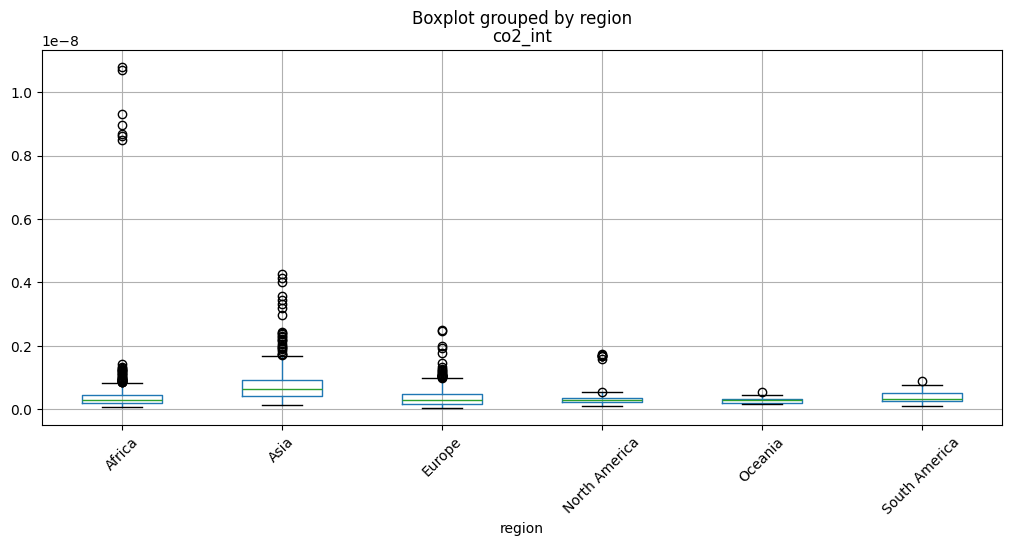

In [6]:
#building the box plot for the data around region.
df.boxplot(column='co2_int', by='region', figsize=(12,5), rot=45)

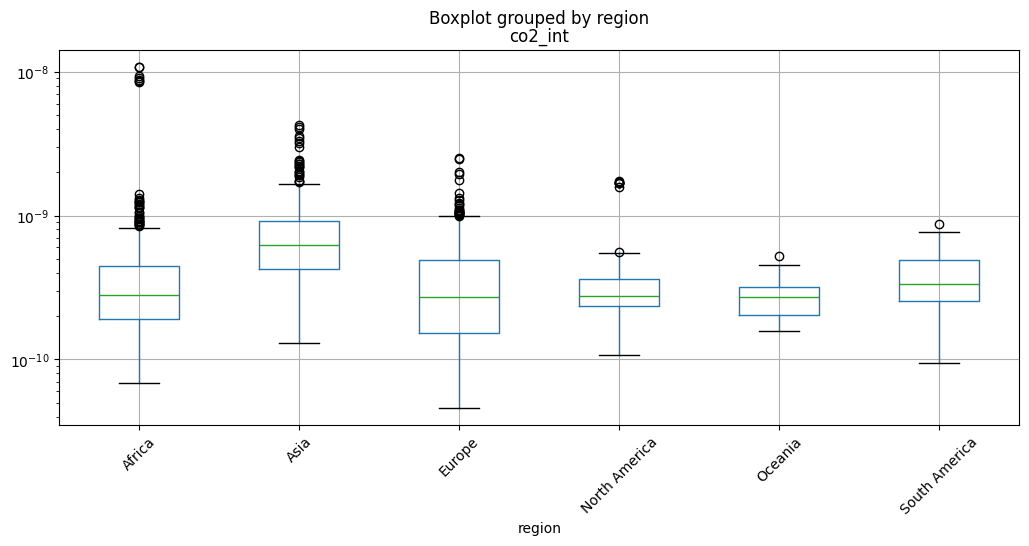

In [8]:
#the scale for every region is different, specially considering Africa with extreme outliers, we fix the visual by 
#adjusting the plot scale:
import matplotlib.pyplot as plt

df.boxplot(column='co2_int', by='region', figsize=(12,5), rot=45)
plt.yscale('log') # This spreads out the squished boxes at the bottom
plt.savefig('../figures/boxplot_outliers_Regions.png', dpi=150, bbox_inches='tight')
plt.show()


#### 2.1.1 Hypothesis 1: scenario A - CO2 intensity through median metric


In [9]:
#selecting just the columns of interest for the CO2 decoupling analysis.
dec_cols=['country', 'year','region','co2_int', 'd_co2_int']
dec_df=df[dec_cols]
dec_df.head(1)


,country,year,region,co2_int,d_co2_int
0,Afghanistan,2014,Asia,4.460237e-10,NaN


In [10]:
piv_dec_df= dec_df.pivot_table(index='year', columns='region', values='co2_int', aggfunc='median')
piv_dec_df


region,Africa,Asia,Europe,North America,Oceania,South America
year,,,,,,
2014,2.331501e-10,5.048535e-10,2.698633e-10,2.945257e-10,2.466248e-10,3.157920e-10
2015,2.769143e-10,6.402478e-10,3.169185e-10,2.981302e-10,2.829628e-10,3.236926e-10
2016,2.851338e-10,6.502523e-10,3.157771e-10,2.810590e-10,2.732150e-10,3.393871e-10
2017,2.882821e-10,6.287676e-10,2.909963e-10,2.603923e-10,2.798619e-10,2.975395e-10
2018,2.656799e-10,5.860888e-10,2.592352e-10,2.624456e-10,2.688449e-10,3.167815e-10
2019,2.974146e-10,5.960364e-10,2.541298e-10,2.672961e-10,2.931350e-10,3.515843e-10
2020,3.020834e-10,7.171447e-10,2.381357e-10,2.774132e-10,2.802312e-10,3.400842e-10


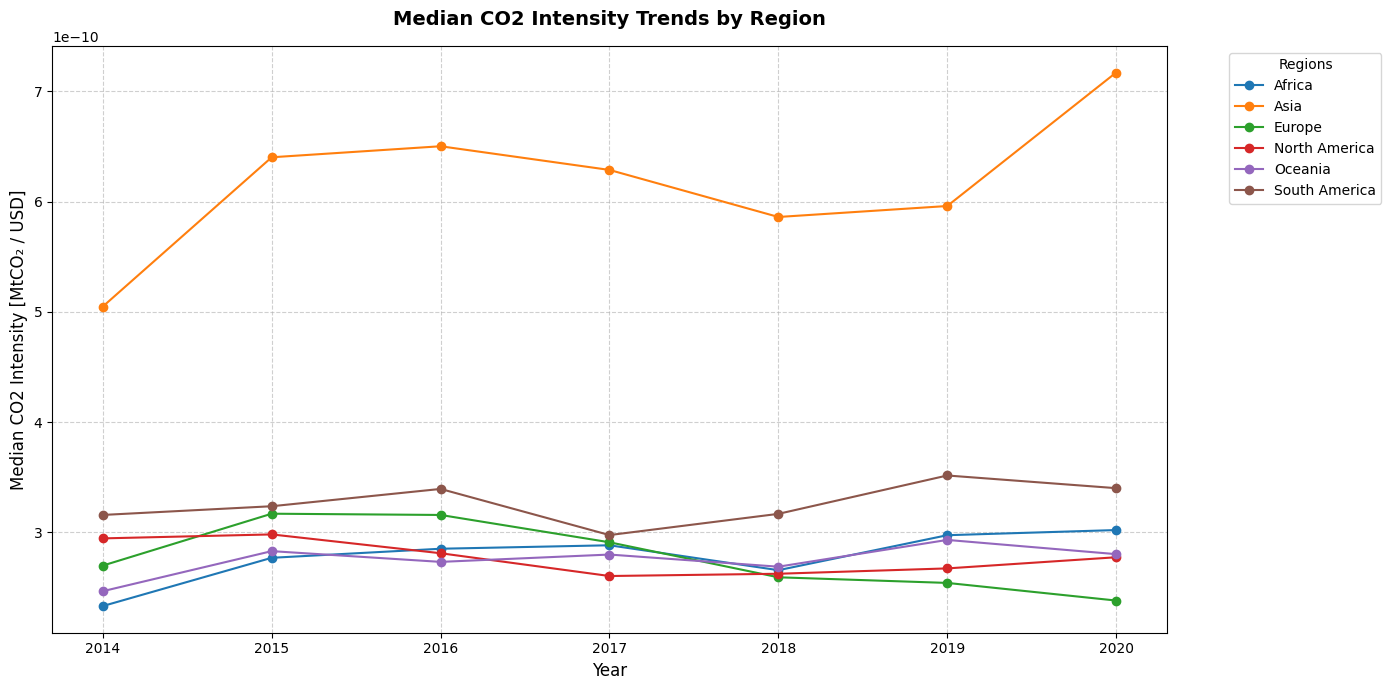

In [11]:
#creating the line plot to see CO2 intensity trend per region
piv_dec_df.plot(kind='line', figsize=(14,7), marker='o')
# Adding clear lables and titles
plt.title('Median CO2 Intensity Trends by Region', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Median CO2 Intensity [MtCO₂ / USD]', fontsize=12)

#Working the layout and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Regions', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../figures/medianCO2Intensity_Regiontrends.png', dpi=150, bbox_inches='tight')
#Rendering the final image
plt.show()



#### 2.1.2 Hypothesis 1: scenario A - CO2 intensity through mean metric


In [12]:
piv2_dec_df= dec_df.pivot_table(index='year', columns='region', values='co2_int', aggfunc='mean')
piv2_dec_df

region,Africa,Asia,Europe,North America,Oceania,South America
year,,,,,,
2014,4.668765e-10,6.954938e-10,3.829745e-10,3.547341e-10,2.653889e-10,3.465572e-10
2015,5.470020e-10,7.440496e-10,4.519618e-10,3.663301e-10,2.959221e-10,3.568485e-10
2016,5.655914e-10,7.986319e-10,4.526765e-10,3.608283e-10,2.856471e-10,3.995574e-10
2017,5.254072e-10,8.357430e-10,4.132040e-10,3.442618e-10,2.706516e-10,3.601619e-10
2018,4.964014e-10,8.240533e-10,3.699191e-10,3.396589e-10,2.674826e-10,3.491505e-10
2019,5.182350e-10,8.363627e-10,3.486078e-10,3.491992e-10,2.733962e-10,3.861752e-10
2020,5.191493e-10,8.794269e-10,3.335929e-10,3.439745e-10,2.788740e-10,4.020666e-10


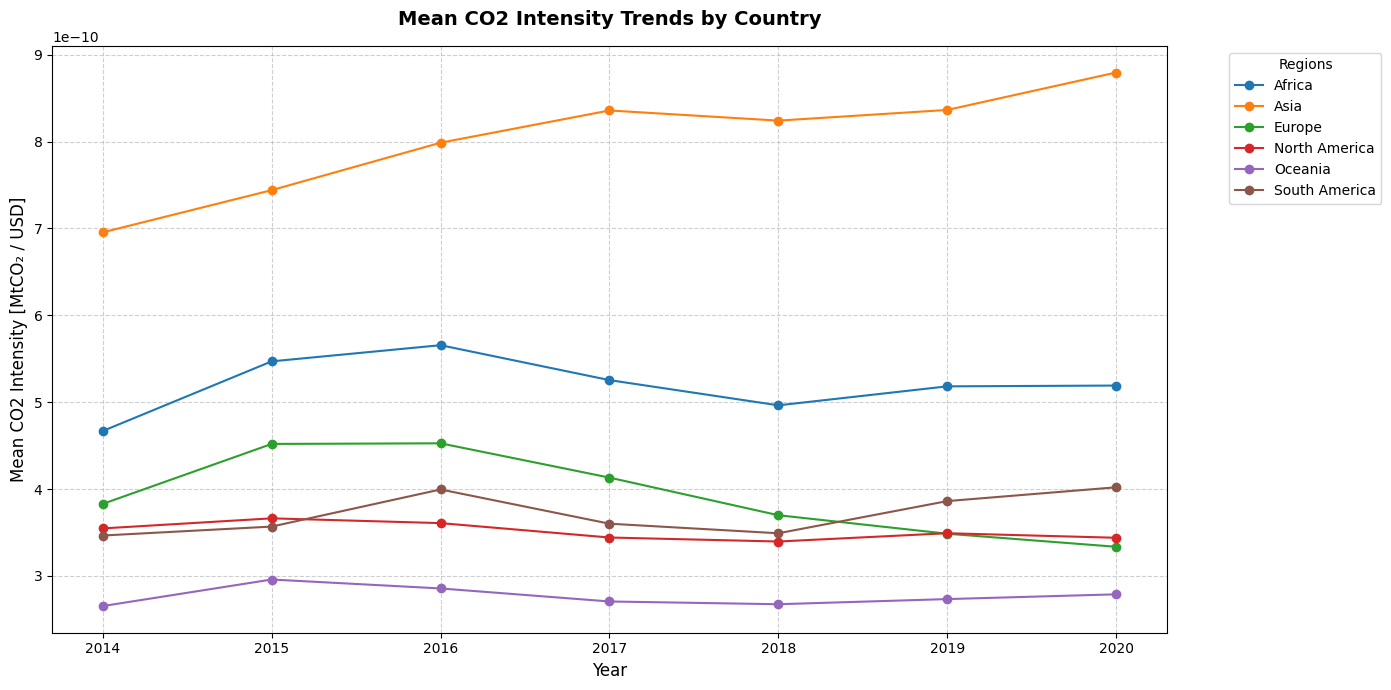

In [13]:
#creating the line plot to see CO2 intensity trend per region
piv2_dec_df.plot(kind='line', figsize=(14,7), marker='o')
# Adding clear lables and titles
plt.title('Mean CO2 Intensity Trends by Country', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean CO2 Intensity [MtCO₂ / USD]', fontsize=12)

#Working the layout and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Regions', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#Rendering the final image
plt.show()

In [14]:
dec_df.head(1)

,country,year,region,co2_int,d_co2_int
0,Afghanistan,2014,Asia,4.460237e-10,NaN


In [15]:
#constructing a function to spot ouliers per region using the Interquartile Range (IQR) as a boxplot would do.

#outliers (from boxplot) are calculated as: lower outliers Q1 - 1.5*IQR & upper ouliers Q3 + 1,5*IQR
#then we need Q1,Q2 and IQR (box hight in the boxplot). IQR is calculated as: Q3-Q1
#IQR is computed per region per ALL years combined — not per region per year, to have stable outlier 
#flag.

#Calculate Q1 and Q3 per region using transform, using .apply deleted my column region! :(
q1_p_reg = dec_df.groupby('region')['co2_int'].transform(lambda x: x.quantile(0.25))
q3_p_reg = dec_df.groupby('region')['co2_int'].transform(lambda x: x.quantile(0.75))

# Calculate IQR based on those regional series
iqr_p_reg = q3_p_reg - q1_p_reg

#Create outlier flag column 
dec_df['outlier'] = (dec_df['co2_int'] < q1_p_reg - 1.5 * iqr_p_reg) |(dec_df['co2_int'] > q3_p_reg + 1.5 * iqr_p_reg)

dec_df.head(5)

,country,year,region,co2_int,d_co2_int,outlier
0,Afghanistan,2014,Asia,4.460237e-10,NaN,False
1,Afghanistan,2015,Asia,5.018510e-10,5.582731e-11,False
2,Afghanistan,2016,Asia,4.722216e-10,-2.962940e-11,False
3,Afghanistan,2017,Asia,4.891723e-10,1.695069e-11,False
4,Afghanistan,2018,Asia,5.404821e-10,5.130980e-11,False


In [16]:
display(dec_df[dec_df['outlier'] == True].country.unique())
dec_df.loc[dec_df['outlier'] == True, ['region', 'country']]

<StringArray>
[               'Algeria',                'Belarus', 'Bosnia and Herzegovina',
                  'Egypt',                   'Iran',                'Jamaica',
             'Kazakhstan',                'Lesotho',                  'Libya',
               'Mongolia',                  'Nauru',            'North Korea',
                 'Russia',                 'Serbia',           'South Africa',
               'Suriname',                  'Syria',               'Tanzania',
    'Trinidad and Tobago',           'Turkmenistan',                'Ukraine',
             'Uzbekistan']
Length: 22, dtype: str

,region,country
15,Africa,Algeria
16,Africa,Algeria
17,Africa,Algeria
18,Africa,Algeria
19,Africa,Algeria
...,...,...
1242,Europe,Ukraine
1243,Europe,Ukraine
1244,Europe,Ukraine
1245,Europe,Ukraine


In [17]:
#Now we can compare mean with and without outliers.
df_w    = dec_df.copy() # ->> dataframe with outlier countries
df_wo = dec_df[dec_df['outlier'] == False].copy() #--> dataframe without the oulier countries

piv_w = df_w.pivot_table(index='year', columns='region', values='co2_int', aggfunc='mean')
piv_wo = df_wo.pivot_table(index='year', columns='region', values='co2_int', aggfunc='mean')


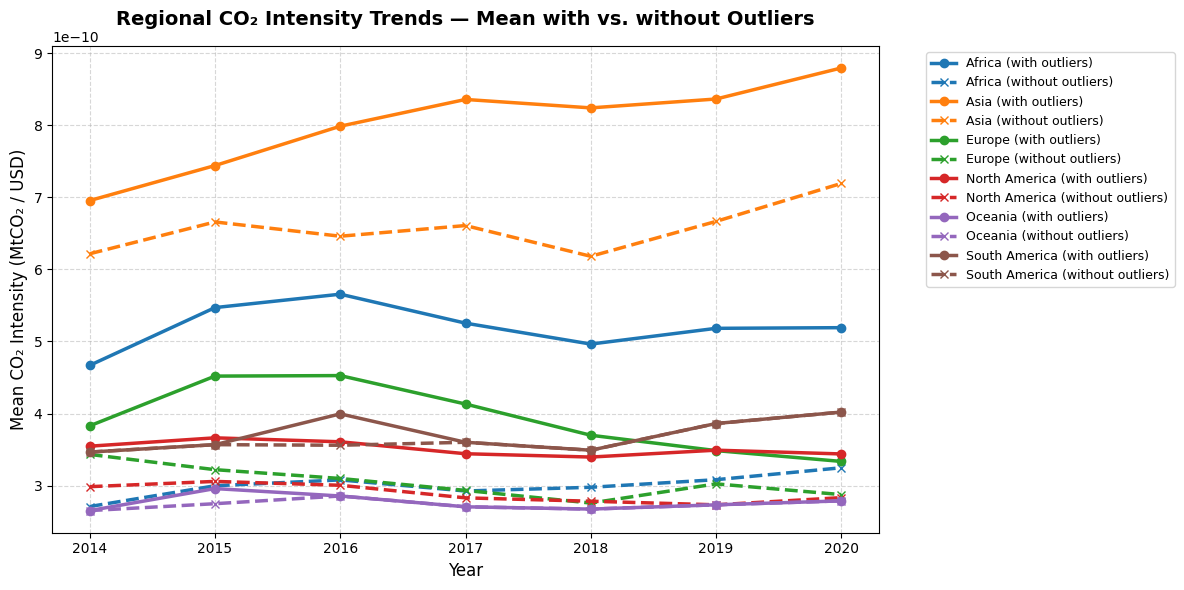

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

# Color per region — same color both lines
colors = plt.cm.tab10.colors

# Loop through columns (regions)
for i, region in enumerate(piv_w.columns):
    
    #Plot 'with outliers' -> X-axis is the index (years), Y-axis is the region column
    ax.plot(piv_w.index, piv_w[region],
            color=colors[i], linewidth=2.5, linestyle='-',
            marker='o', label=f'{region} (with outliers)')
    
    #Plot 'without outliers' -> X-axis is the index (years), Y-axis is the region column
    ax.plot(piv_wo.index, piv_wo[region],
            color=colors[i], linewidth=2.5, linestyle='--',
            marker='x', label=f'{region} (without outliers)')

# Formatting the labels and layout
ax.set_title('Regional CO₂ Intensity Trends — Mean with vs. without Outliers', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean CO₂ Intensity (MtCO₂ / USD)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

# Clear X-axis ticks for each year
ax.set_xticks(piv_w.index)

# Handle the legend outside to the right
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/h1_outlier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()




#### 2.1.3 Hypothesis 1: scenario A - CO2 intensity endpoint delta


In [19]:
# get 2014 and 2020 values per country
endpoint = dec_df[dec_df['year'].isin([2014, 2020])]
endpoint = endpoint.pivot_table(index=['region','country'], columns='year', values='co2_int')
endpoint.head(5)


year                         2014          2020
region country                                 
Africa Algeria       6.379550e-10  1.038000e-09
       Angola        1.586647e-10  2.487850e-10
       Benin         3.593666e-10  3.532231e-10
       Botswana      4.428006e-10  4.147454e-10
       Burkina Faso  2.056600e-10  3.169572e-10

In [20]:
endpoint.columns = ['co2_int_2014', 'co2_int_2020']
endpoint['delta'] = endpoint['co2_int_2020'] - endpoint['co2_int_2014']


In [21]:
endpoint.head(1)

,,co2_int_2014,co2_int_2020,delta
region,country,,,
Africa,Algeria,6.379550e-10,1.038000e-09,4.000446e-10


In [22]:
display(endpoint.isnull().any())

co2_int_2014    False
co2_int_2020    False
delta           False
dtype: bool

/var/folders/y7/p6n8z7nn4fs88vn9n57nxbh40000gn/T/ipykernel_12243/809403113.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


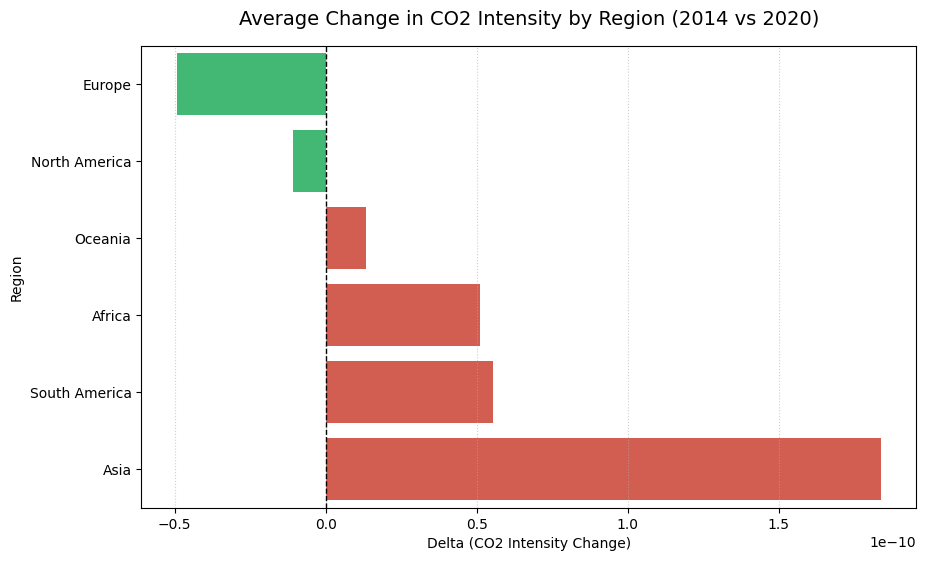

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# aggregating data y region (averaging or summing the delta)
region_delta = endpoint.groupby('region')['delta'].mean().sort_values().reset_index()

# Plotting
plt.figure(figsize=(10, 6))
# Fixing colors to show good or bad shift, green for negative delta (decline), red for positive (increase)
colors = ['#2ecc71' if x < 0 else '#e74c3c' for x in region_delta['delta']]

sns.barplot(
    x='delta', 
    y='region', 
    data=region_delta, 
    palette=colors
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1) # Zero line
plt.title('Average Change in CO2 Intensity by Region (2014 vs 2020)', fontsize=14, pad=15)
plt.xlabel('Delta (CO2 Intensity Change)')
plt.ylabel('Region')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.savefig('../figures/AvgChange_CO2intens_Regions.png', dpi=150, bbox_inches='tight')
plt.show()

 ### 2.2 Hypothesis 1: scenario B

Has the CO₂ intensity of GDP (co2 / GDP) declined across regions from 2014 to 2020 — and does the answer change depending on how we measure emissions?

> **Scenario B: CO2 emissions including land-use change (co2_luc / GDP)**

**CO2 with land-use, intensity metric (co2_luc_int)**: given by CO2_luc/GDP aslo decoupling indicator, but the honest view.
**Delta of CO2 intensity with land-use (d_co2_luc_int)**: rate of decoupling from CO2 with land-use.

In [24]:
# Computing the CO2 intensity indicator:
#co2 is measured in million tonnes and GDP is in international-$ in 2011 prices ($)
df['co2_luc_int'] = df['co2_luc']/df['GDP'] #--> scenario B

In [25]:
# Computing the rate of decoupling from CO2 including lad-use case
#Order was already done previuosly in scenario A
# Now that they are ordered, we compute the delta (delta = year - previous year data).
df['d_co2_luc_int']= df.groupby('country')['co2_luc_int'].diff() ## for the first year it give NaN

### 2.3 Hypothesis 2: renewable adoption vs. CO2 intensity

Where renewable energy adoption has grown, has CO₂ intensity actually fallen — and where is the gap largest?

In [26]:
df.head(1)

,country,year,prct_access_elec,prct_renew_prod,renew_prod_kwh,prct_renew_cons,co2,co2_luc,prim_ener_cons,region,GDP,population,gdp_per_cap,co2_int,d_co2_int,co2_luc_int,d_co2_luc_int
0,Afghanistan,2014,89.5,2.77201,32440000.0,19.1,8.697668,8.776041,26.630217,Asia,1.950046e+10,32792523.0,594.661805,4.460237e-10,NaN,4.500427e-10,NaN


In [27]:
#Sorting values to make sure they are organised chronologically

df= df.sort_values(['country', 'year']).reset_index(drop=True)
#since the scales of CO2 intensity are in tons and renewable production in percentage for each year, 
#we need to normalise to % change.

df['d_co2_int_pct'] = df.groupby('country')['co2_int'].pct_change()
df['d_renew_prod_pct'] = df.groupby('country')['prct_renew_prod'].pct_change()
df['d_renew_cons_pct'] = df.groupby('country')['prct_renew_cons'].pct_change()


In [28]:
df.head(1)

,country,year,prct_access_elec,prct_renew_prod,renew_prod_kwh,prct_renew_cons,co2,co2_luc,prim_ener_cons,region,GDP,population,gdp_per_cap,co2_int,d_co2_int,co2_luc_int,d_co2_luc_int,d_co2_int_pct,d_renew_prod_pct,d_renew_cons_pct
0,Afghanistan,2014,89.5,2.77201,32440000.0,19.1,8.697668,8.776041,26.630217,Asia,1.950046e+10,32792523.0,594.661805,4.460237e-10,NaN,4.500427e-10,NaN,NaN,NaN,NaN


In [29]:
#selecting just the columns of interest for the CO2 decoupling analysis.
chg_cols=['country', 'year','region','d_co2_int_pct','d_renew_prod_pct','d_renew_cons_pct']
chg_df=df[chg_cols]
chg_df.head(5)

,country,year,region,d_co2_int_pct,d_renew_prod_pct,d_renew_cons_pct
0,Afghanistan,2014,Asia,NaN,NaN,NaN
1,Afghanistan,2015,Asia,0.125167,0.021746,-0.073298
2,Afghanistan,2016,Asia,-0.059040,0.126318,0.141243
3,Afghanistan,2017,Asia,0.035896,-0.006710,-0.034653
4,Afghanistan,2018,Asia,0.104891,0.096379,-0.061538


In [30]:
reg_chg = chg_df.groupby(['region','year'])[['d_co2_int_pct','d_renew_prod_pct','d_renew_cons_pct']].median().reset_index()


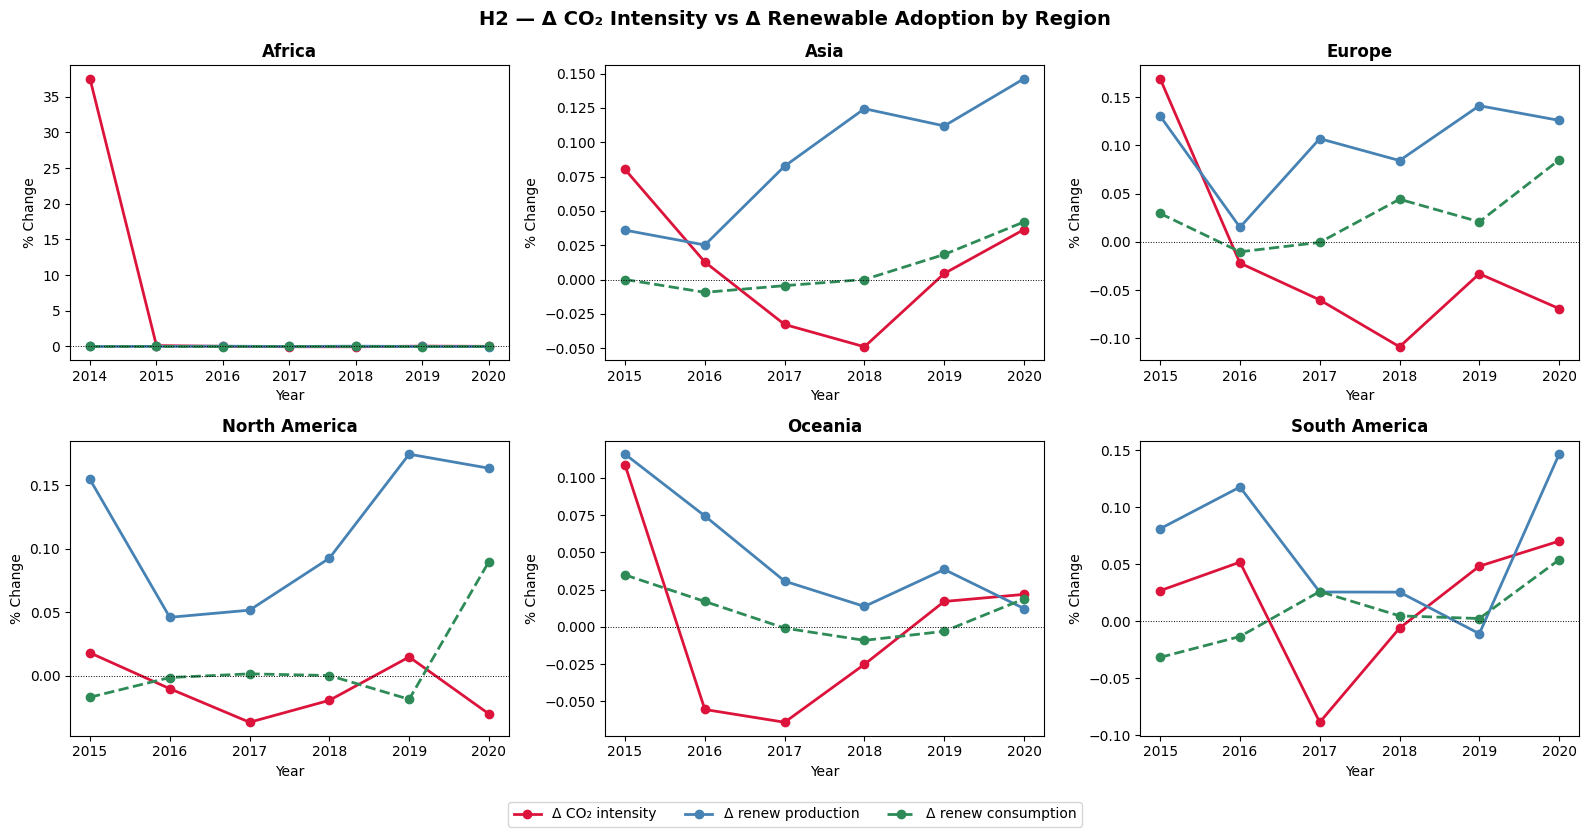

In [31]:
#To examine better the trends and compare, we plot each region separately.

regions = reg_chg['region'].unique()
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=False)
axes = axes.flatten()

for i, region in enumerate(regions):
    ax = axes[i]
    data = reg_chg[reg_chg['region'] == region]
    
    ax.plot(data['year'], data['d_co2_int_pct'],    color='crimson',  linewidth=2, marker='o', label='Δ CO₂ intensity')
    ax.plot(data['year'], data['d_renew_prod_pct'], color='steelblue', linewidth=2, marker='o', label='Δ renew production')
    ax.plot(data['year'], data['d_renew_cons_pct'], color='seagreen',  linewidth=2, marker='o', linestyle='--', label='Δ renew consumption')
    
    ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
    ax.set_title(region, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('% Change')

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('H2 — Δ CO₂ Intensity vs Δ Renewable Adoption by Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/h2_regional_decoupling.png', dpi=150, bbox_inches='tight')
plt.show()

From the above graph we see:
* Renewables driving decoupling: this would be seen if renewable production goes in the opposite direction as CO2 change. This trend is visible for Asia [2016-2019], Europe [2016-2017] and for South America just happens for one year. Not visible at all for North America, Oceania.
  
* The "exporting clean energy" signal: we  see a gap between production and conssumption lines, when production increases but consumption stays flat or decreases signals that the region has increase the export of energy. This happened for Asia [2016-2018], Europe specially for 2018, North America [2016-2019], and slighly for South America in the last period.

* Based on the above, it is not possible to conclude that increased of renewable production drives the CO2 intensity change. There could be many other drivers as the trends change in different ways for each region.

* Africa seems to have some wrong data, investigation to be continued.....!!!! 

---
## 3. XXX Analysis

### 3.1 Computing the XXXX

**Computing XXX** = explanation of analysis....TBD per XXXX over 2014–2024.

- **Explanation of value X** → bla bla bla → **decoupling** ✅  
- **Explanation of value X** → bla bla bla → **coupling** ❌

We define X like:  
```
x variable = asdfad - pyadlkf
```

---
## X. Summary of Findings

> **Fill this in after running all cells. Replace placeholders with your actual values.**

### Hypothesis Result



### Key Observations

1. **[X group] countries** showed the highest bla bla bla `[X]%`.
2. The top blablba blab was **[country]** with a index of ... `[value]`.
3. Regional CO₂ trends show `[describe pattern]`.
4. Energy intensity `[fell / rose / was flat]` in high-income countries over 2014–2024.

### Limitations

- `prim_ener_cons` had `[X]%` nulls — imputation strategy may affect energy section results.

- 2020–2021 COVID does not show an impact by artificially suppressing CO₂ as expected.

### Next Steps

